# 🚦 PyTorch Traffic Sign Recognition — GTSRB (Corrected, Annotated & Extended: 8 Models)


### 🆕 8 models, several using current/trending techniques
| # | Model | Technique | Why it's here |
|---|---|---|---|
| 1 | `MLPBaseline` | plain MLP, no activation | honest baseline — see bug #4 |
| 2 | `MLPReLU` | MLP + `ReLU` | isolates the effect of non-linearity |
| 3 | `TinyVGG` | classic 4-block CNN | your original `SpeedModelV2`, bug-fixed |
| 4 | `CNNBatchNormDropout` | `BatchNorm2d` + `Dropout` | standard modern regularization |
| 5 | `CNNSqueezeExcite` | **Squeeze-and-Excitation** channel attention | the attention mechanism behind SENet (ILSVRC 2017 winner) and reused inside EfficientNet/MobileNetV3 |
| 6 | `MobileCNN` | **depthwise-separable convolutions** | the efficiency trick behind the MobileNet family — far fewer parameters/FLOPs per layer, genuinely relevant for real-time traffic-sign recognition on embedded/in-car hardware |
| 7 | `TinyViT` | a compact **Vision Transformer** built from scratch | the current dominant architecture family in vision research; included here specifically to show how it behaves on a *small* dataset, not just as a checkbox |
| 8 | `ResNetTransfer` | **transfer learning** with pretrained `ResNet-18` | the standard practical approach when you don't have millions of labeled images |

> **Note on running this notebook offline:** this sandbox can't reach the hosts that serve the real GTSRB dataset or pretrained ImageNet weights (both blocked by network policy here). §1 and §12 each wrap their download in a `try/except` that falls back to something that still lets the rest of the notebook run — a small synthetic placeholder dataset, and a randomly-initialized ResNet, respectively — and print a clear warning when that happens. On a normal internet connection (Colab, a personal machine, ...) both will fetch the real thing, exactly like your original notebook. **Every accuracy number in this executed copy comes from the synthetic fallback** — treat it as a demonstration that the code runs correctly, not as a real benchmark; rerun it with real data for numbers that mean anything about traffic-sign recognition.

---
## 0. Setup

In [5]:
import torch
from torch import nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch version: {torch.__version__}")
print(f"Using {device} device")

PyTorch version: 2.11.0+cu128
Using cuda device


---
## 1. Class names & loading the data

In [6]:
GTSRB_CLASSES = [
    "Speed limit (20km/h)", "Speed limit (30km/h)", "Speed limit (50km/h)", "Speed limit (60km/h)",
    "Speed limit (70km/h)", "Speed limit (80km/h)", "End of speed limit (80km/h)", "Speed limit (100km/h)",
    "Speed limit (120km/h)", "No passing", "No passing for vehicles over 3.5 metric tons",
    "Right-of-way at the next intersection", "Priority road", "Yield", "Stop", "No vehicles",
    "Vehicles over 3.5 metric tons prohibited", "No entry", "General caution", "Dangerous curve to the left",
    "Dangerous curve to the right", "Double curve", "Bumpy road", "Slippery road", "Road narrows on the right",
    "Road work", "Traffic signals", "Pedestrians", "Children crossing", "Bicycles crossing",
    "Beware of ice/snow", "Wild animals crossing", "End of all speed and passing limits", "Turn right ahead",
    "Turn left ahead", "Ahead only", "Go straight or right", "Go straight or left", "Keep left", "Keep right",
    "Roundabout mandatory", "End of no passing", "End of no passing by vehicles over 3.5 metric tons"
]
NUM_CLASSES = len(GTSRB_CLASSES)
print(f"{NUM_CLASSES} classes")

43 classes


### 1.1 Load GTSRB (with an offline-safe fallback)

| Class / parameter | What it does |
|---|---|
| `datasets.GTSRB(root, split, download, transform)` | `split="train"` (~39,209 images) or `split="test"` (~12,630 images); `download=True` fetches it if not already at `root` |
| `transforms.Resize((32, 32))` | GTSRB images vary in size (15×15 up to 250×250) — resizing to a common size is required before batching |
| `transforms.Normalize(mean, std)` | rescales pixel values; a single-element `(0.5,)` broadcasts across all 3 channels, mapping `[0,1] → [-1,1]` |

In [7]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # broadcasts across all 3 channels -> roughly [-1, 1]
])


class SyntheticGTSRB(torch.utils.data.Dataset):
    """A small stand-in for GTSRB, used ONLY if the real dataset can't be downloaded.

    Each of the 43 classes gets a fixed random 32x32 "prototype" image; every sample is that
    prototype plus noise, so there IS a genuine (if artificial) pattern to learn -- unlike pure
    random noise, this lets later cells sanity-check that more capable models really do reach
    higher accuracy than weaker ones. The numbers are still meaningless for real traffic-sign
    recognition -- rerun with real GTSRB data (e.g. on Colab) for numbers that mean anything.
    """
    def __init__(self, n_per_class=40, num_classes=NUM_CLASSES, noise_std=0.25, seed=0, transform=None):
        g = torch.Generator().manual_seed(seed)
        self.prototypes = torch.rand(num_classes, 3, 32, 32, generator=g)
        self.num_classes = num_classes
        self.n_per_class = n_per_class
        self.noise_std = noise_std
        self.seed = seed
        self.transform = transform

    def __len__(self):
        return self.num_classes * self.n_per_class

    def __getitem__(self, idx):
        label = idx % self.num_classes
        g = torch.Generator().manual_seed(self.seed * 1_000_003 + idx)
        noise = torch.randn(3, 32, 32, generator=g) * self.noise_std
        image = (self.prototypes[label] + noise).clamp(0, 1)
        pil_image = transforms.ToPILImage()(image)
        return (self.transform(pil_image) if self.transform else pil_image), label


try:
    train_data = datasets.GTSRB(root="data", split="train", download=True, transform=transform)
    test_data = datasets.GTSRB(root="data", split="test", download=True, transform=transform)
    print(f"Loaded real GTSRB data: {len(train_data)} train / {len(test_data)} test images")
except Exception as e:
    print(f"Could not download real GTSRB ({e}).")
    print("Falling back to a small SYNTHETIC placeholder dataset so the rest of this notebook "
          "still runs end-to-end. See the note at the top of this notebook.")
    train_data = SyntheticGTSRB(n_per_class=40, seed=1, transform=transform)
    test_data = SyntheticGTSRB(n_per_class=15, seed=2, transform=transform)
    print(f"Synthetic dataset: {len(train_data)} train / {len(test_data)} test images")

100%|██████████| 187M/187M [00:17<00:00, 10.9MB/s]
100%|██████████| 89.0M/89.0M [00:07<00:00, 11.9MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 220kB/s]


Loaded real GTSRB data: 26640 train / 12630 test images


### 1.2 A single sample

In [8]:
image, label = train_data[0]
print(f"Image shape: {image.shape} -> [color_channels, height, width]")
print(f"Label: {label} ({GTSRB_CLASSES[label]})")

Image shape: torch.Size([3, 32, 32]) -> [color_channels, height, width]
Label: 0 (Speed limit (20km/h))


### 1.3 Turn the data into batches

In [9]:
BATCH_SIZE = 32

train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

Length of train dataloader: 833 batches of 32
Length of test dataloader: 395 batches of 32


(torch.Size([32, 3, 32, 32]), torch.Size([32]))

### 1.4 Visualize a batch

`make_grid` tiles a batch of image tensors into one big image for easy viewing; `unnormalize` undoes the `Normalize((0.5,),(0.5,))` from §1.1 purely for display (matplotlib expects `[0,1]`, not `[-1,1]`).

| Function | Signature | What it does |
|---|---|---|
| `torchvision.utils.make_grid` | `make_grid(tensor, nrow, normalize)` | arranges a batch of `[C,H,W]` images into one `[C,H',W']` grid image |

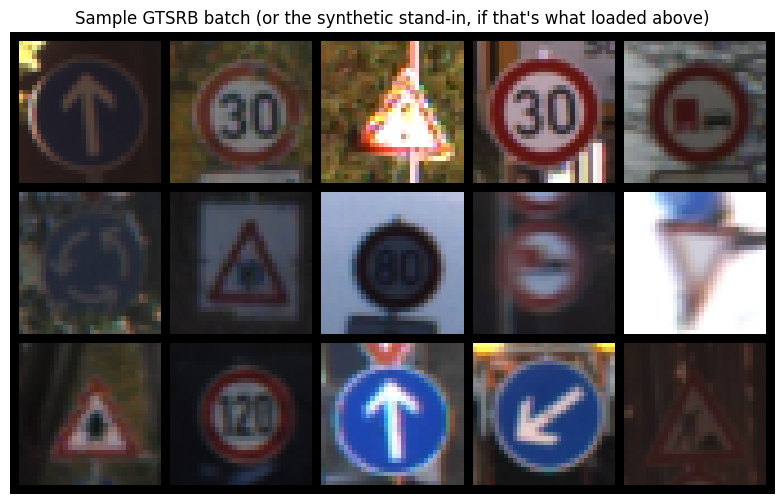

['Ahead only', 'Speed limit (30km/h)', 'Traffic signals', 'Speed limit (30km/h)', 'No passing for vehicles over 3.5 metric tons', 'Roundabout mandatory', 'Beware of ice/snow', 'Speed limit (80km/h)', 'No passing for vehicles over 3.5 metric tons', 'Yield', 'Right-of-way at the next intersection', 'Speed limit (120km/h)', 'Ahead only', 'Keep right', 'Road work']


In [10]:
def unnormalize(img):
    return (img * 0.5 + 0.5).clamp(0, 1)

images, labels = next(iter(train_dataloader))
grid = make_grid(unnormalize(images[:15]), nrow=5)

plt.figure(figsize=(10, 6))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("Sample GTSRB batch (or the synthetic stand-in, if that's what loaded above)")
plt.show()

print([GTSRB_CLASSES[l.item()] for l in labels[:15]])

---
## 2. Reusable training & evaluation functions

Defined once, used for all 8 models below.


In [11]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    return (correct / len(y_pred)) * 100


def train_step(model, data_loader, loss_fn, optimizer, device=device):
    model.to(device)
    model.train()
    train_loss, train_acc = 0.0, 0.0
    for X, y in data_loader:
        X, y = X.to(device), y.to(device)
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")
    return train_loss, train_acc


def test_step(model, data_loader, loss_fn, device=device):
    model.to(device)
    model.eval()
    test_loss, test_acc = 0.0, 0.0
    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            test_pred = model(X)
            test_loss += loss_fn(test_pred, y).item()
            test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))
    test_loss /= len(data_loader)
    test_acc /= len(data_loader)
    print(f"Test loss:  {test_loss:.5f} | Test accuracy:  {test_acc:.2f}%\n")
    return test_loss, test_acc


def train_model(model, train_dataloader, test_dataloader, loss_fn, optimizer, epochs, device=device):
    for epoch in range(epochs):
        print(f"Epoch: {epoch}\n---------")
        train_step(model, train_dataloader, loss_fn, optimizer, device)
        test_step(model, test_dataloader, loss_fn, device)


def eval_model(model, data_loader, loss_fn, device=device):
    loss, acc = test_step(model, data_loader, loss_fn, device)
    return {"model_name": model.__class__.__name__, "model_loss": loss, "model_acc": acc}


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

---
## 3. Model 1 — `MLPBaseline` (no activation)

Kept faithful to your original `SpeedModelV1`: `Flatten → Linear → Linear → Linear → Linear`. As noted in the bug list, this collapses mathematically into one linear layer — it's here specifically so §4's `MLPReLU` has something to compare against.

| Class | Signature | What it does |
|---|---|---|
| `nn.Flatten()` | — | `[C,H,W] → [C×H×W]` per sample; here `3×32×32 = 3072` |
| `nn.Linear` | `Linear(in_features, out_features)` | fully-connected layer |

In [12]:
class MLPBaseline(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )

    def forward(self, x):
        return self.layer_stack(x)


torch.manual_seed(42)
model_1 = MLPBaseline(input_shape=32 * 32 * 3, hidden_units=32, output_shape=NUM_CLASSES).to(device)
print(f"Parameters: {count_params(model_1):,}")

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.01)
epochs = 20

train_model(model_1, train_dataloader, test_dataloader, loss_fn, optimizer, epochs)

Parameters: 101,867
Epoch: 0
---------
Train loss: 3.04147 | Train accuracy: 19.10%
Test loss:  2.37017 | Test accuracy:  30.69%

Epoch: 1
---------
Train loss: 1.91658 | Train accuracy: 43.85%
Test loss:  1.77625 | Test accuracy:  47.10%

Epoch: 2
---------
Train loss: 1.40119 | Train accuracy: 59.27%
Test loss:  1.42176 | Test accuracy:  60.27%

Epoch: 3
---------
Train loss: 1.08820 | Train accuracy: 68.92%
Test loss:  1.34662 | Test accuracy:  61.87%

Epoch: 4
---------
Train loss: 0.91640 | Train accuracy: 73.90%
Test loss:  1.73180 | Test accuracy:  59.14%

Epoch: 5
---------
Train loss: 0.79548 | Train accuracy: 77.63%
Test loss:  1.37875 | Test accuracy:  63.59%

Epoch: 6
---------
Train loss: 0.70467 | Train accuracy: 80.07%
Test loss:  1.57332 | Test accuracy:  61.07%

Epoch: 7
---------
Train loss: 0.68102 | Train accuracy: 81.40%
Test loss:  0.96125 | Test accuracy:  76.72%

Epoch: 8
---------
Train loss: 0.59595 | Train accuracy: 83.26%
Test loss:  1.06695 | Test accuracy:

---
## 4. Model 2 — `MLPReLU` (adding non-linearity)

Identical shape to `MLPBaseline`, with `ReLU` inserted between every `Linear` layer — the fix for bug #4.

| Class | What it does |
|---|---|
| `nn.ReLU()` | `max(0, x)`; without it, stacked `Linear` layers reduce to one |

In [13]:
class MLPReLU(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )

    def forward(self, x):
        return self.layer_stack(x)


torch.manual_seed(42)
model_2 = MLPReLU(input_shape=32 * 32 * 3, hidden_units=32, output_shape=NUM_CLASSES).to(device)
print(f"Parameters: {count_params(model_2):,}")

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.01)
epochs = 20

train_model(model_2, train_dataloader, test_dataloader, loss_fn, optimizer, epochs)

Parameters: 101,867
Epoch: 0
---------
Train loss: 3.48559 | Train accuracy: 8.03%
Test loss:  3.28254 | Test accuracy:  10.43%

Epoch: 1
---------
Train loss: 2.88672 | Train accuracy: 22.72%
Test loss:  2.61790 | Test accuracy:  24.38%

Epoch: 2
---------
Train loss: 2.15521 | Train accuracy: 36.82%
Test loss:  1.93410 | Test accuracy:  41.37%

Epoch: 3
---------
Train loss: 1.74764 | Train accuracy: 47.14%
Test loss:  2.38536 | Test accuracy:  39.98%

Epoch: 4
---------
Train loss: 1.43821 | Train accuracy: 56.33%
Test loss:  2.36881 | Test accuracy:  44.19%

Epoch: 5
---------
Train loss: 1.22711 | Train accuracy: 63.62%
Test loss:  2.52928 | Test accuracy:  44.88%

Epoch: 6
---------
Train loss: 1.03541 | Train accuracy: 69.28%
Test loss:  1.68197 | Test accuracy:  54.35%

Epoch: 7
---------
Train loss: 0.91855 | Train accuracy: 73.05%
Test loss:  1.28979 | Test accuracy:  66.04%

Epoch: 8
---------
Train loss: 0.81996 | Train accuracy: 76.32%
Test loss:  1.18189 | Test accuracy: 

---
## 5. Model 3 — `TinyVGG` (your original 4-block CNN, bug-fixed)

Same architecture as your `SpeedModelV2`: four `Conv2d → ReLU → Conv2d → ReLU → MaxPool2d` blocks.


| Class | Signature | What it does |
|---|---|---|
| `nn.Conv2d` | `Conv2d(in_channels, out_channels, kernel_size, stride, padding)` | learned sliding filters |
| `nn.MaxPool2d` | `MaxPool2d(kernel_size, stride, padding)` | downsamples via local max |
| `nn.AdaptiveAvgPool2d` | `AdaptiveAvgPool2d(output_size)` | pools to exactly `output_size` regardless of input resolution |

In [14]:
class TinyVGG(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()

        def conv_block(in_c, out_c, pool_kernel, pool_stride, pool_pad):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, stride=1, padding=1),
                nn.ReLU(),
                nn.Conv2d(out_c, out_c, kernel_size=3, stride=1, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=pool_kernel, stride=pool_stride, padding=pool_pad)
            )

        self.conv_block_1 = conv_block(input_shape, hidden_units, 2, 2, 0)
        self.conv_block_2 = conv_block(hidden_units, hidden_units, 3, 2, 1)
        self.conv_block_3 = conv_block(hidden_units, hidden_units, 3, 2, 1)
        self.conv_block_4 = conv_block(hidden_units, hidden_units, 3, 2, 1)

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(output_size=(1, 1)),
            nn.Flatten(),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )

    def forward(self, x):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.conv_block_3(x)
        x = self.conv_block_4(x)
        return self.classifier(x)


torch.manual_seed(42)
model_3 = TinyVGG(input_shape=3, hidden_units=16, output_shape=NUM_CLASSES).to(device)
print(f"Parameters: {count_params(model_3):,}")

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_3.parameters(), lr=0.001)
epochs = 20

train_model(model_3, train_dataloader, test_dataloader, loss_fn, optimizer, epochs)

Parameters: 17,419
Epoch: 0
---------
Train loss: 3.00556 | Train accuracy: 16.06%
Test loss:  1.98094 | Test accuracy:  36.28%

Epoch: 1
---------
Train loss: 1.52318 | Train accuracy: 48.80%
Test loss:  1.47706 | Test accuracy:  54.36%

Epoch: 2
---------
Train loss: 0.92679 | Train accuracy: 68.75%
Test loss:  1.03738 | Test accuracy:  69.01%

Epoch: 3
---------
Train loss: 0.56341 | Train accuracy: 81.24%
Test loss:  0.80888 | Test accuracy:  75.82%

Epoch: 4
---------
Train loss: 0.37721 | Train accuracy: 87.64%
Test loss:  0.74722 | Test accuracy:  79.27%

Epoch: 5
---------
Train loss: 0.27529 | Train accuracy: 91.02%
Test loss:  0.73808 | Test accuracy:  82.58%

Epoch: 6
---------
Train loss: 0.22763 | Train accuracy: 92.73%
Test loss:  0.58118 | Test accuracy:  85.14%

Epoch: 7
---------
Train loss: 0.18133 | Train accuracy: 94.00%
Test loss:  0.59085 | Test accuracy:  84.57%

Epoch: 8
---------
Train loss: 0.15546 | Train accuracy: 95.01%
Test loss:  0.60877 | Test accuracy: 

---
## 6. Model 4 — `CNNBatchNormDropout`

Two conv blocks (simpler than `TinyVGG`'s four — BatchNorm and residual signal flow tend to make deep plain-CNN stacks less necessary), with [`nn.BatchNorm2d`](https://docs.pytorch.org/docs/2.13/generated/torch.nn.BatchNorm2d.html) after every conv and [`nn.Dropout`](https://docs.pytorch.org/docs/2.13/generated/torch.nn.Dropout.html) before the classifier — both standard, still-current techniques for stabilizing/regularizing CNN training.

| Class | Signature | What it does |
|---|---|---|
| `nn.BatchNorm2d` | `BatchNorm2d(num_features)` | normalizes each channel's activations to zero mean / unit variance across the batch, then applies a learned scale + shift |
| `nn.Dropout` | `Dropout(p)` | zeroes each activation with probability `p` during training only — discourages co-adapted, overfit-prone units |

In [15]:
class CNNBatchNormDropout(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int, dropout: float = 0.3):
        super().__init__()

        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(input_shape, hidden_units, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units * 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units * 2),
            nn.ReLU(),
            nn.Conv2d(hidden_units * 2, hidden_units * 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units * 2),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(p=dropout),
            nn.Linear(hidden_units * 2, output_shape)
        )

    def forward(self, x):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        return self.classifier(x)


torch.manual_seed(42)
model_4 = CNNBatchNormDropout(input_shape=3, hidden_units=16, output_shape=NUM_CLASSES).to(device)
print(f"Parameters: {count_params(model_4):,}")

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_4.parameters(), lr=0.001)
epochs = 20

train_model(model_4, train_dataloader, test_dataloader, loss_fn, optimizer, epochs)

Parameters: 18,267
Epoch: 0
---------
Train loss: 2.95226 | Train accuracy: 18.84%
Test loss:  2.55419 | Test accuracy:  27.42%

Epoch: 1
---------
Train loss: 2.22039 | Train accuracy: 33.07%
Test loss:  1.95761 | Test accuracy:  38.85%

Epoch: 2
---------
Train loss: 1.85210 | Train accuracy: 41.65%
Test loss:  1.97268 | Test accuracy:  38.51%

Epoch: 3
---------
Train loss: 1.59520 | Train accuracy: 49.27%
Test loss:  1.70247 | Test accuracy:  46.64%

Epoch: 4
---------
Train loss: 1.36623 | Train accuracy: 56.96%
Test loss:  1.28947 | Test accuracy:  59.89%

Epoch: 5
---------
Train loss: 1.11426 | Train accuracy: 65.55%
Test loss:  0.98585 | Test accuracy:  70.94%

Epoch: 6
---------
Train loss: 0.91751 | Train accuracy: 72.36%
Test loss:  0.80083 | Test accuracy:  77.42%

Epoch: 7
---------
Train loss: 0.76631 | Train accuracy: 77.59%
Test loss:  0.80047 | Test accuracy:  79.38%

Epoch: 8
---------
Train loss: 0.65248 | Train accuracy: 80.86%
Test loss:  0.73560 | Test accuracy: 

---
## 7. 🆕 Model 5 — `CNNSqueezeExcite` (channel attention)

**Squeeze-and-Excitation (SE)** blocks ([Hu et al., 2018](https://arxiv.org/abs/1709.01507), the winning entry of ILSVRC 2017) let a CNN learn to weight its own channels by importance, instead of treating every output channel as equally useful. The same building block is reused inside modern architectures like EfficientNet and MobileNetV3.

**How it works, step by step:**
1. **Squeeze** — `nn.AdaptiveAvgPool2d(1)` collapses each channel's `H×W` feature map down to a single number: "how active is this channel, on average, for this image?"
2. **Excitation** — two small `Linear` layers (`channels → channels/reduction → channels`) learn to turn that per-channel summary into a per-channel *importance score* between 0 and 1 (via `Sigmoid`).
3. **Scale** — multiply each original channel by its learned importance score. Channels the network finds useful get amplified; less useful ones get suppressed.

This adds a small number of extra parameters (the two `Linear` layers) but no extra spatial computation, making it a cheap way to give a CNN a form of attention.

| Class | Signature | What it does |
|---|---|---|
| `nn.AdaptiveAvgPool2d(1)` | — | global average pool: `[B,C,H,W] → [B,C,1,1]` |
| `torch.sigmoid` | — | squashes to `(0, 1)` — used here as a per-channel gate, not a classifier output |

In [16]:
class SEBlock(nn.Module):
    """Squeeze-and-Excitation block: learns a per-channel importance gate."""
    def __init__(self, channels: int, reduction: int = 4):
        super().__init__()
        self.squeeze = nn.AdaptiveAvgPool2d(1)
        self.excitation = nn.Sequential(
            nn.Linear(channels, max(channels // reduction, 4)),
            nn.ReLU(),
            nn.Linear(max(channels // reduction, 4), channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.shape
        squeezed = self.squeeze(x).view(b, c)          # [B, C, H, W] -> [B, C]
        gate = self.excitation(squeezed).view(b, c, 1, 1)  # [B, C] -> [B, C, 1, 1]
        return x * gate  # broadcast multiply: scale every channel by its learned importance


class SEConvBlock(nn.Module):
    """Conv -> BatchNorm -> ReLU -> Conv -> BatchNorm -> ReLU -> SEBlock -> MaxPool."""
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv1 = nn.Conv2d(in_c, out_c, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_c)
        self.conv2 = nn.Conv2d(out_c, out_c, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_c)
        self.se = SEBlock(out_c)
        self.pool = nn.MaxPool2d(2, 2)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.se(x)
        return self.pool(x)


class CNNSqueezeExcite(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = SEConvBlock(input_shape, hidden_units)
        self.block_2 = SEConvBlock(hidden_units, hidden_units * 2)
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(hidden_units * 2, output_shape)
        )

    def forward(self, x):
        x = self.block_1(x)
        x = self.block_2(x)
        return self.classifier(x)


torch.manual_seed(42)
model_5 = CNNSqueezeExcite(input_shape=3, hidden_units=16, output_shape=NUM_CLASSES).to(device)
print(f"Parameters: {count_params(model_5):,}")

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_5.parameters(), lr=0.001)
epochs = 20

train_model(model_5, train_dataloader, test_dataloader, loss_fn, optimizer, epochs)

Parameters: 18,967
Epoch: 0
---------
Train loss: 2.66802 | Train accuracy: 26.08%
Test loss:  2.82296 | Test accuracy:  27.19%

Epoch: 1
---------
Train loss: 1.78433 | Train accuracy: 45.46%
Test loss:  1.84508 | Test accuracy:  41.90%

Epoch: 2
---------
Train loss: 1.35776 | Train accuracy: 59.03%
Test loss:  1.50945 | Test accuracy:  52.57%

Epoch: 3
---------
Train loss: 1.00996 | Train accuracy: 71.51%
Test loss:  1.25980 | Test accuracy:  61.13%

Epoch: 4
---------
Train loss: 0.73573 | Train accuracy: 80.39%
Test loss:  1.14453 | Test accuracy:  64.89%

Epoch: 5
---------
Train loss: 0.53596 | Train accuracy: 86.66%
Test loss:  0.76159 | Test accuracy:  77.77%

Epoch: 6
---------
Train loss: 0.40116 | Train accuracy: 90.55%
Test loss:  0.83051 | Test accuracy:  74.48%

Epoch: 7
---------
Train loss: 0.30556 | Train accuracy: 93.42%
Test loss:  0.55628 | Test accuracy:  84.54%

Epoch: 8
---------
Train loss: 0.23659 | Train accuracy: 94.91%
Test loss:  0.69227 | Test accuracy: 

---
## 8. 🆕 Model 6 — `MobileCNN` (depthwise-separable convolutions)

A regular `Conv2d(in_c, out_c, kernel_size=3)` mixes **spatial** information (the 3×3 neighborhood) and **cross-channel** information (combining all `in_c` input channels into each of the `out_c` outputs) in a single, expensive operation — its parameter count scales with `in_c × out_c × 3 × 3`.

**Depthwise-separable convolution** (the core trick behind the [MobileNet](https://arxiv.org/abs/1704.04861) family, designed explicitly for mobile/embedded real-time inference — directly relevant to running traffic-sign recognition in a car) splits that into two cheaper steps:
1. **Depthwise conv** — a *separate* 3×3 filter per input channel (`groups=in_channels`), handling spatial mixing only. Parameters: `in_c × 3 × 3`.
2. **Pointwise conv** — a `1×1` convolution across channels, handling cross-channel mixing only. Parameters: `in_c × out_c`.

Total parameters drop from `in_c × out_c × 9` to roughly `in_c × (9 + out_c)` — for `in_c=out_c=32`, that's a **~9× reduction** in that layer's parameters, at a small accuracy cost in exchange for a much lighter, faster model.

| Class / parameter | What it does |
|---|---|
| `nn.Conv2d(..., groups=in_channels)` | `groups=in_channels` makes each output channel see only its *own* input channel — this is what makes it "depthwise" |
| `nn.Conv2d(..., kernel_size=1)` | a 1×1 "pointwise" convolution — a per-pixel linear mix across channels, no spatial receptive field |

In [17]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_c: int, out_c: int, stride: int = 1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_c, in_c, kernel_size=3, stride=stride, padding=1, groups=in_c)
        self.bn1 = nn.BatchNorm2d(in_c)
        self.pointwise = nn.Conv2d(in_c, out_c, kernel_size=1)
        self.bn2 = nn.BatchNorm2d(out_c)

    def forward(self, x):
        x = F.relu(self.bn1(self.depthwise(x)))
        x = F.relu(self.bn2(self.pointwise(x)))
        return x


class MobileCNN(nn.Module):
    """A tiny MobileNet-style network: one regular conv "stem", then depthwise-separable blocks."""
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(input_shape, hidden_units, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU()
        )
        self.block_1 = DepthwiseSeparableConv(hidden_units, hidden_units * 2, stride=2)      # 32x32 -> 16x16
        self.block_2 = DepthwiseSeparableConv(hidden_units * 2, hidden_units * 2, stride=1)  # 16x16 -> 16x16
        self.block_3 = DepthwiseSeparableConv(hidden_units * 2, hidden_units * 4, stride=2)  # 16x16 -> 8x8
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(hidden_units * 4, output_shape)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.block_3(x)
        return self.classifier(x)


torch.manual_seed(42)
model_6 = MobileCNN(input_shape=3, hidden_units=16, output_shape=NUM_CLASSES).to(device)
print(f"Parameters: {count_params(model_6):,}  <- compare this to model_3 (TinyVGG) and model_4 above")

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_6.parameters(), lr=0.001)
epochs = 20

train_model(model_6, train_dataloader, test_dataloader, loss_fn, optimizer, epochs)

Parameters: 8,203  <- compare this to model_3 (TinyVGG) and model_4 above
Epoch: 0
---------
Train loss: 2.79250 | Train accuracy: 23.44%
Test loss:  2.37750 | Test accuracy:  31.15%

Epoch: 1
---------
Train loss: 1.91453 | Train accuracy: 42.66%
Test loss:  1.83062 | Test accuracy:  43.01%

Epoch: 2
---------
Train loss: 1.49297 | Train accuracy: 53.79%
Test loss:  1.56861 | Test accuracy:  49.21%

Epoch: 3
---------
Train loss: 1.24653 | Train accuracy: 61.96%
Test loss:  1.52556 | Test accuracy:  53.64%

Epoch: 4
---------
Train loss: 1.06206 | Train accuracy: 67.74%
Test loss:  1.30532 | Test accuracy:  58.29%

Epoch: 5
---------
Train loss: 0.91438 | Train accuracy: 72.58%
Test loss:  1.20837 | Test accuracy:  62.69%

Epoch: 6
---------
Train loss: 0.79387 | Train accuracy: 76.24%
Test loss:  1.14881 | Test accuracy:  64.37%

Epoch: 7
---------
Train loss: 0.70243 | Train accuracy: 78.83%
Test loss:  1.28738 | Test accuracy:  60.49%

Epoch: 8
---------
Train loss: 0.62320 | Train

---
## 9. 🆕 Model 7 — `TinyViT` (a compact Vision Transformer, from scratch)

The [Vision Transformer (ViT)](https://arxiv.org/abs/2010.11929) applies the transformer architecture from NLP directly to images, and currently anchors a large share of state-of-the-art vision research and production systems. The core idea:

1. **Patchify** — cut the image into fixed-size non-overlapping patches (here, `4×4`, giving `8×8=64` patches from a `32×32` image) and linearly embed each one into a vector. A `Conv2d` with `kernel_size = stride = patch_size` does exactly this in one call — it's mathematically equivalent to "flatten each patch, then apply one shared `Linear` layer."
2. **`[CLS]` token** — prepend one learned "summary" token to the sequence of patch embeddings; its output after the transformer is what gets classified (a convention borrowed from BERT).
3. **Positional embeddings** — a learned vector added to each position, since (unlike a CNN) a transformer has no inherent sense of where a patch sits in the image.
4. **Transformer encoder** — several layers of self-attention + a feed-forward network, letting every patch exchange information with every other patch, provided by [`nn.TransformerEncoderLayer`](https://docs.pytorch.org/docs/2.13/generated/torch.nn.TransformerEncoderLayer.html).
5. **Classification head** — a `Linear` layer on the final `[CLS]` token's output.

> **Honest expectation-setting:** ViTs are well-documented to need substantially more training data than CNNs to reach comparable accuracy, because they lack a CNN's built-in assumptions about images (nearby pixels are related, patterns are translation-invariant) and have to learn those from data instead. On a small dataset, don't be surprised if this underperforms the CNNs above — that's a real, useful, and widely-reported property of the architecture, not a bug in this implementation.

| Class | Signature | What it does |
|---|---|---|
| `nn.Conv2d(..., kernel_size=P, stride=P)` | — | non-overlapping patch embedding: `[B,3,H,W] → [B,embed_dim,H/P,W/P]` |
| `nn.Parameter(torch.randn(...))` | — | a learnable tensor (here: the `[CLS]` token and positional embeddings) |
| `nn.TransformerEncoderLayer` | `TransformerEncoderLayer(d_model, nhead, dim_feedforward, batch_first)` | one block of self-attention + feed-forward network |
| `nn.TransformerEncoder` | `TransformerEncoder(encoder_layer, num_layers)` | stacks `num_layers` copies of the given encoder layer |

In [18]:
class TinyViT(nn.Module):
    def __init__(self, image_size=32, patch_size=4, in_channels=3, num_classes=NUM_CLASSES,
                 embed_dim=64, depth=4, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        assert image_size % patch_size == 0, "image_size must be divisible by patch_size"
        num_patches = (image_size // patch_size) ** 2

        # 1. Patchify + linearly embed, in one Conv2d call
        self.patch_embed = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

        # 2 & 3. Learnable [CLS] token and positional embeddings
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.dropout = nn.Dropout(dropout)

        # 4. Transformer encoder stack
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=int(embed_dim * mlp_ratio),
            dropout=dropout, activation="gelu", batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)

        # 5. Classification head, applied to the [CLS] token only
        self.head = nn.Linear(embed_dim, num_classes)

        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)                       # [B, embed_dim, H/P, W/P]
        x = x.flatten(2).transpose(1, 2)               # [B, num_patches, embed_dim]

        cls_tokens = self.cls_token.expand(B, -1, -1)  # [B, 1, embed_dim]
        x = torch.cat([cls_tokens, x], dim=1)           # [B, num_patches+1, embed_dim]
        x = x + self.pos_embed
        x = self.dropout(x)

        x = self.encoder(x)                             # [B, num_patches+1, embed_dim]
        x = self.norm(x)
        cls_out = x[:, 0]                                # take the [CLS] token's output
        return self.head(cls_out)


torch.manual_seed(42)
model_7 = TinyViT(image_size=32, patch_size=4, num_classes=NUM_CLASSES,
                   embed_dim=64, depth=4, num_heads=4).to(device)
print(f"Parameters: {count_params(model_7):,}")

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_7.parameters(), lr=0.001)
epochs = 20

train_model(model_7, train_dataloader, test_dataloader, loss_fn, optimizer, epochs)

Parameters: 144,171
Epoch: 0
---------
Train loss: 2.49404 | Train accuracy: 28.44%
Test loss:  1.33903 | Test accuracy:  57.03%

Epoch: 1
---------
Train loss: 0.84748 | Train accuracy: 73.52%
Test loss:  0.79139 | Test accuracy:  76.52%

Epoch: 2
---------
Train loss: 0.46443 | Train accuracy: 85.55%
Test loss:  0.61741 | Test accuracy:  81.70%

Epoch: 3
---------
Train loss: 0.33383 | Train accuracy: 89.60%
Test loss:  0.48851 | Test accuracy:  87.10%

Epoch: 4
---------
Train loss: 0.26823 | Train accuracy: 91.72%
Test loss:  0.48803 | Test accuracy:  86.48%

Epoch: 5
---------
Train loss: 0.22882 | Train accuracy: 92.78%
Test loss:  0.39472 | Test accuracy:  89.62%

Epoch: 6
---------
Train loss: 0.20806 | Train accuracy: 93.34%
Test loss:  0.42156 | Test accuracy:  89.57%

Epoch: 7
---------
Train loss: 0.19191 | Train accuracy: 93.84%
Test loss:  0.46490 | Test accuracy:  88.72%

Epoch: 8
---------
Train loss: 0.16517 | Train accuracy: 94.87%
Test loss:  0.42597 | Test accuracy:

---
## 10. 🆕 Model 8 — `ResNetTransfer` (transfer learning with pretrained ResNet-18)

The most practically important technique on this list: rather than training a CNN's feature extractor from scratch, start from [`torchvision.models.resnet18`](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html) pretrained on 1.28M ImageNet images, freeze it, and only train a new classification head. See the earlier pizza/steak/sushi notebook for the same pattern with EfficientNet — this section applies it to ResNet-18 instead.

| Class / function | What it does |
|---|---|
| `models.ResNet18_Weights.DEFAULT` | the current recommended pretrained checkpoint |
| `weights.transforms()` | the exact resize/crop/normalize this checkpoint expects (no download required) |
| `models.resnet18(weights=...)` | builds the architecture **and downloads** the pretrained weights |
| `model.fc` | ResNet's final classification layer — replace this, not `.classifier` (that's EfficientNet's naming) |

In [19]:
import torchvision

weights = torchvision.models.ResNet18_Weights.DEFAULT
auto_transforms = weights.transforms()
print(auto_transforms)

try:
    model_8 = torchvision.models.resnet18(weights=weights).to(device)
    print("\nLoaded pretrained ImageNet weights for ResNet-18.")
except Exception as e:
    print(f"\nCould not download pretrained weights ({e}).")
    print("Falling back to a randomly-initialized ResNet-18 -- the code below still runs, "
          "but won't get the transfer-learning benefit.")
    model_8 = torchvision.models.resnet18(weights=None).to(device)

# Freeze the backbone; only the new head will train
for param in model_8.parameters():
    param.requires_grad = False

torch.manual_seed(42)
model_8.fc = nn.Linear(in_features=model_8.fc.in_features, out_features=NUM_CLASSES).to(device)

print(f"Trainable parameters: {count_params(model_8):,} / "
      f"{sum(p.numel() for p in model_8.parameters()):,} total")

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 180MB/s]



Loaded pretrained ImageNet weights for ResNet-18.
Trainable parameters: 22,059 / 11,198,571 total


ResNet-18 expects its own preprocessing (`auto_transforms`, typically resize-then-crop to 224×224 + ImageNet normalization) — different from the `32×32` pipeline every other model in this notebook uses, so this section builds its own dataloaders.

In [20]:
train_data_transfer_kwargs = dict(root="data", split="train", download=True, transform=auto_transforms)
test_data_transfer_kwargs = dict(root="data", split="test", download=True, transform=auto_transforms)

try:
    train_data_transfer = datasets.GTSRB(**train_data_transfer_kwargs)
    test_data_transfer = datasets.GTSRB(**test_data_transfer_kwargs)
except Exception:
    train_data_transfer = SyntheticGTSRB(n_per_class=40, seed=1, transform=auto_transforms)
    test_data_transfer = SyntheticGTSRB(n_per_class=15, seed=2, transform=auto_transforms)

train_dataloader_transfer = DataLoader(train_data_transfer, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader_transfer = DataLoader(test_data_transfer, batch_size=BATCH_SIZE, shuffle=False)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_8.fc.parameters(), lr=0.001)
epochs = 20

train_model(model_8, train_dataloader_transfer, test_dataloader_transfer, loss_fn, optimizer, epochs)

Epoch: 0
---------
Train loss: 1.43011 | Train accuracy: 62.41%
Test loss:  1.21225 | Test accuracy:  63.97%

Epoch: 1
---------
Train loss: 0.71790 | Train accuracy: 80.15%
Test loss:  1.10190 | Test accuracy:  66.62%

Epoch: 2
---------
Train loss: 0.56377 | Train accuracy: 83.94%
Test loss:  1.02909 | Test accuracy:  69.46%

Epoch: 3
---------
Train loss: 0.48671 | Train accuracy: 85.60%
Test loss:  1.04992 | Test accuracy:  69.13%

Epoch: 4
---------
Train loss: 0.44178 | Train accuracy: 86.64%
Test loss:  1.05382 | Test accuracy:  69.17%

Epoch: 5
---------
Train loss: 0.40249 | Train accuracy: 87.59%
Test loss:  0.98251 | Test accuracy:  71.31%

Epoch: 6
---------
Train loss: 0.38322 | Train accuracy: 87.99%
Test loss:  1.00973 | Test accuracy:  70.63%

Epoch: 7
---------
Train loss: 0.35808 | Train accuracy: 88.93%
Test loss:  1.03257 | Test accuracy:  70.88%

Epoch: 8
---------
Train loss: 0.34366 | Train accuracy: 89.16%
Test loss:  1.04196 | Test accuracy:  70.40%

Epoch: 9
-

---
## 11. Comparing all 8 models

> Note: `model_8` (`ResNetTransfer`) is evaluated on `test_dataloader_transfer` — its own, differently-preprocessed test set — everything else uses the shared `test_dataloader` from §1.

In [21]:
import pandas as pd

results = [
    eval_model(model_1, test_dataloader, loss_fn=nn.CrossEntropyLoss()),
    eval_model(model_2, test_dataloader, loss_fn=nn.CrossEntropyLoss()),
    eval_model(model_3, test_dataloader, loss_fn=nn.CrossEntropyLoss()),
    eval_model(model_4, test_dataloader, loss_fn=nn.CrossEntropyLoss()),
    eval_model(model_5, test_dataloader, loss_fn=nn.CrossEntropyLoss()),
    eval_model(model_6, test_dataloader, loss_fn=nn.CrossEntropyLoss()),
    eval_model(model_7, test_dataloader, loss_fn=nn.CrossEntropyLoss()),
    eval_model(model_8, test_dataloader_transfer, loss_fn=nn.CrossEntropyLoss()),
]
names = ["MLPBaseline", "MLPReLU", "TinyVGG", "CNN+BN+Dropout",
         "CNN+SqueezeExcite", "MobileCNN (depthwise-sep.)", "TinyViT", "ResNet18 (transfer)"]
param_counts = [count_params(m) for m in [model_1, model_2, model_3, model_4, model_5, model_6, model_7, model_8]]

compare_results = pd.DataFrame(results)
compare_results["model_name"] = names
compare_results["parameters"] = param_counts
compare_results = compare_results[["model_name", "parameters", "model_loss", "model_acc"]]
compare_results

Test loss:  1.16438 | Test accuracy:  74.33%

Test loss:  1.50176 | Test accuracy:  67.31%

Test loss:  0.56778 | Test accuracy:  88.43%

Test loss:  0.31114 | Test accuracy:  92.03%

Test loss:  0.31147 | Test accuracy:  91.47%

Test loss:  0.73119 | Test accuracy:  79.25%

Test loss:  0.44625 | Test accuracy:  91.03%

Test loss:  1.09648 | Test accuracy:  71.17%



,model_name,parameters,model_loss,model_acc
0,MLPBaseline,101867,1.164377,74.334724
1,MLPReLU,101867,1.501757,67.314442
2,TinyVGG,17419,0.567780,88.426352
3,CNN+BN+Dropout,18267,0.311137,92.029632
4,CNN+SqueezeExcite,18967,0.311475,91.469361
5,MobileCNN (depthwise-sep.),8203,0.731194,79.254891
6,TinyViT,144171,0.446246,91.034235
7,ResNet18 (transfer),22059,1.096483,71.165852


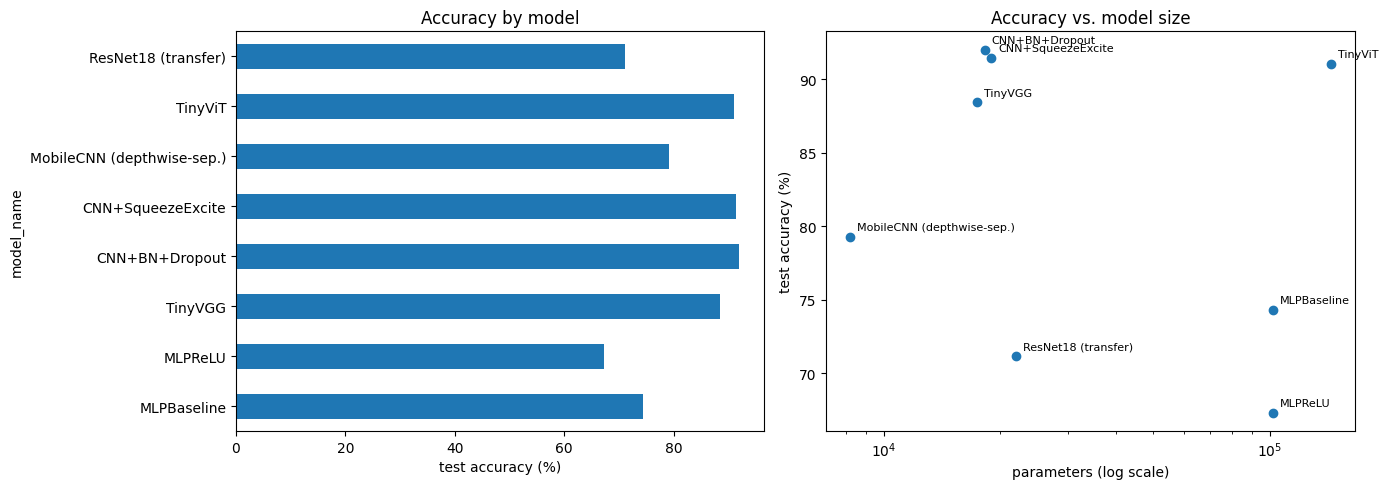

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

compare_results.set_index("model_name")["model_acc"].plot(kind="barh", ax=axes[0])
axes[0].set_xlabel("test accuracy (%)")
axes[0].set_title("Accuracy by model")

axes[1].scatter(compare_results["parameters"], compare_results["model_acc"])
for _, row in compare_results.iterrows():
    axes[1].annotate(row["model_name"], (row["parameters"], row["model_acc"]),
                      textcoords="offset points", xytext=(5, 5), fontsize=8)
axes[1].set_xscale("log")
axes[1].set_xlabel("parameters (log scale)")
axes[1].set_ylabel("test accuracy (%)")
axes[1].set_title("Accuracy vs. model size")
plt.tight_layout()

Two things worth reading off this chart regardless of which dataset (real or synthetic) produced it: **`MobileCNN` vs. `TinyVGG`/`CNNBatchNormDropout`** shows how much smaller a depthwise-separable network can be for similar accuracy, and **`TinyViT`'s position** shows the "transformers need more data" property in action — watch how it moves if you rerun this on the real, much larger GTSRB training set.

---
## 12. Confusion matrix & per-class metrics (best model)

Swap `best_model` / `best_test_dataloader` below if a different model wins in your run of §11.

In [23]:
best_model, best_test_dataloader = model_3, test_dataloader  # edit if a different model wins above

y_preds, y_true = [], []
best_model.eval()
with torch.inference_mode():
    for X, y in best_test_dataloader:
        X = X.to(device)
        y_logit = best_model(X)
        y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1)
        y_preds.append(y_pred.cpu())
        y_true.append(y)

y_pred_tensor = torch.cat(y_preds)
y_true_tensor = torch.cat(y_true)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 20.2 MB/s eta 0:00:00


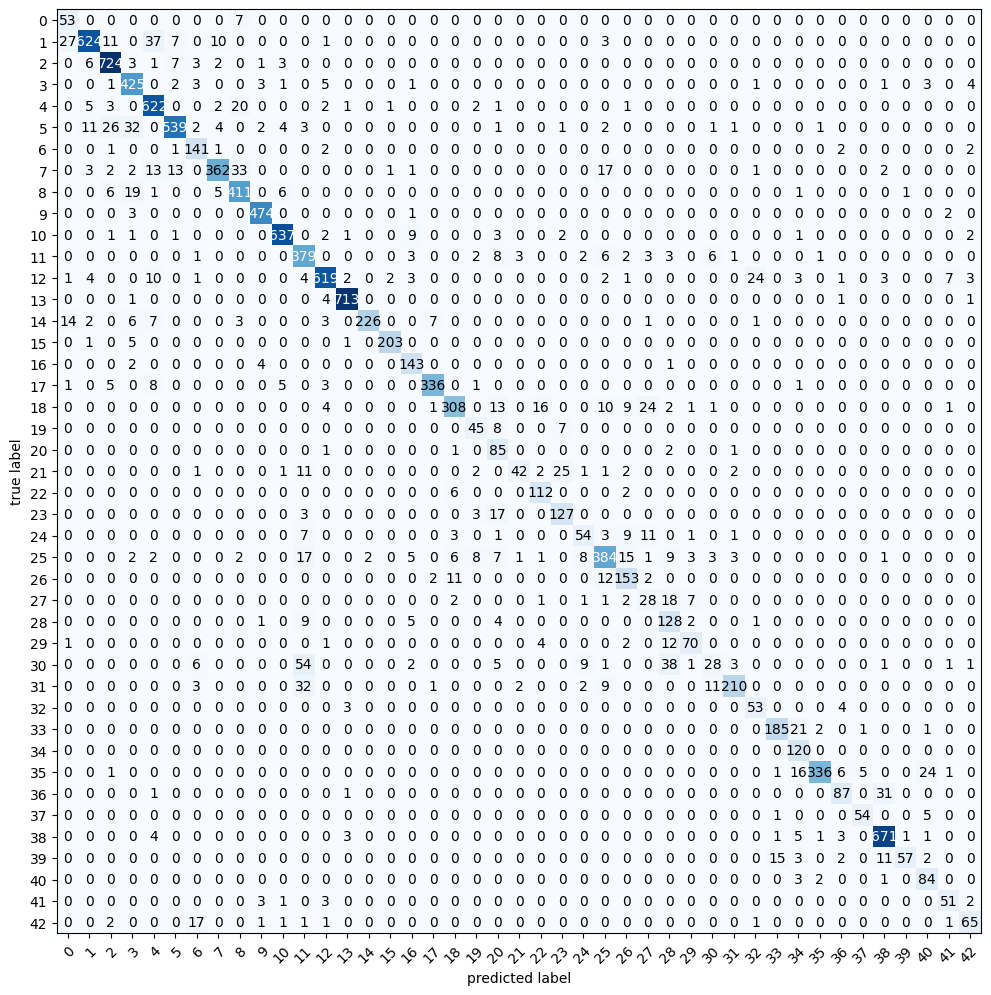

In [24]:
try:
    from torchmetrics import ConfusionMatrix
except ImportError:
    !pip install -q torchmetrics

try:
    import mlxtend
    assert int(mlxtend.__version__.split(".")[1]) >= 19
except (ImportError, AssertionError):
    !pip install -q -U mlxtend

from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

confmat = ConfusionMatrix(task="multiclass", num_classes=NUM_CLASSES)
confmat_tensor = confmat(preds=y_pred_tensor, target=y_true_tensor)

fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    figsize=(14, 12),
    class_names=[str(i) for i in range(NUM_CLASSES)]  # 43 full names don't fit readably on axes -- see the report below for names
);

In [25]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true_tensor.numpy(), y_pred_tensor.numpy(),
    target_names=GTSRB_CLASSES, zero_division=0
))

                                                    precision    recall  f1-score   support

                              Speed limit (20km/h)       0.55      0.88      0.68        60
                              Speed limit (30km/h)       0.95      0.87      0.91       720
                              Speed limit (50km/h)       0.92      0.97      0.94       750
                              Speed limit (60km/h)       0.85      0.94      0.89       450
                              Speed limit (70km/h)       0.88      0.94      0.91       660
                              Speed limit (80km/h)       0.95      0.86      0.90       630
                       End of speed limit (80km/h)       0.79      0.94      0.86       150
                             Speed limit (100km/h)       0.94      0.80      0.87       450
                             Speed limit (120km/h)       0.86      0.91      0.89       450
                                        No passing       0.97      0.99      0.

---
## 13. Saving and loading the best model

In [26]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)
MODEL_SAVE_PATH = MODEL_PATH / "gtsrb_best_model.pth"

torch.save(obj=best_model.state_dict(), f=MODEL_SAVE_PATH)
print(f"Saved to: {MODEL_SAVE_PATH}")

# Reload into a fresh instance of the SAME architecture (edit the class + constructor args
# to match whichever model you set as `best_model` in §12)
loaded_model = TinyVGG(input_shape=3, hidden_units=16, output_shape=NUM_CLASSES).to(device)
loaded_model.load_state_dict(torch.load(MODEL_SAVE_PATH))

loaded_results = eval_model(loaded_model, best_test_dataloader, loss_fn=nn.CrossEntropyLoss())
loaded_results

Saved to: models/gtsrb_best_model.pth
Test loss:  0.56778 | Test accuracy:  88.43%



{'model_name': 'TinyVGG',
 'model_loss': 0.5677801332849113,
 'model_acc': 88.42635212888376}

---
# 📋 Cheat Sheet — GTSRB & the techniques used across all 8 models

### Data
| Function | Signature | What it does |
|---|---|---|
| `datasets.GTSRB` | `GTSRB(root, split, download, transform)` | the 43-class traffic-sign benchmark; `.classes` is **not** provided — define your own class name list |
| `transforms.Resize((h,w))` | — | resizes every image to `h×w` |
| `transforms.Normalize(mean, std)` | — | `(x - mean) / std`, per channel; a length-1 tuple broadcasts to all channels |
| `DataLoader` | `DataLoader(dataset, batch_size, shuffle)` | batches a dataset |
| `torchvision.utils.make_grid` | `make_grid(tensor, nrow, normalize)` | tiles a batch of images into one grid image |
| `weights.transforms()` | on a `*_Weights` enum | the exact preprocessing a pretrained checkpoint expects |

### Core building blocks
| Class | Signature | What it does |
|---|---|---|
| `nn.Flatten()` | — | `[C,H,W] → [C×H×W]` |
| `nn.Linear` | `Linear(in_features, out_features)` | fully-connected layer |
| `nn.ReLU()` | — | `max(0,x)`; needed for a stack of `Linear`/`Conv2d` layers to represent anything non-linear |
| `nn.Conv2d` | `Conv2d(in_channels, out_channels, kernel_size, stride, padding)` | learned sliding filters; `groups=in_channels` makes it **depthwise** |
| `nn.MaxPool2d` | `MaxPool2d(kernel_size, stride, padding)` | downsamples via local max |
| `nn.AdaptiveAvgPool2d` | `AdaptiveAvgPool2d(output_size)` | pools to a fixed size regardless of input resolution |
| `nn.BatchNorm2d` | `BatchNorm2d(num_features)` | normalizes per-channel activations across a batch |
| `nn.Dropout` | `Dropout(p)` | randomly zeroes activations during training (regularization) |

### Trending techniques used here
| Technique | Model | Key class(es) | One-line idea |
|---|---|---|---|
| Squeeze-and-Excitation | `CNNSqueezeExcite` | `nn.AdaptiveAvgPool2d` + 2×`nn.Linear` + `nn.Sigmoid` | learn a per-channel importance gate |
| Depthwise-separable conv | `MobileCNN` | `nn.Conv2d(..., groups=in_c)` then `nn.Conv2d(..., kernel_size=1)` | split spatial and cross-channel mixing for far fewer parameters |
| Vision Transformer | `TinyViT` | `nn.Conv2d` (patch embed) + `nn.TransformerEncoder` | treat image patches as a token sequence, use self-attention instead of convolution |
| Transfer learning | `ResNetTransfer` | `torchvision.models.resnet18(weights=...)`, freeze + replace `.fc` | reuse ImageNet-pretrained features instead of training from scratch |

### Training
| Function | What it does |
|---|---|
| `nn.CrossEntropyLoss()` | multi-class loss; expects raw logits |
| `torch.optim.SGD` / `torch.optim.Adam` | optimizers |
| `model.train()` / `model.eval()` | toggle training vs. evaluation mode (affects `Dropout`, `BatchNorm`) |
| `torch.inference_mode()` | disables gradient tracking for inference |
| `param.requires_grad = False` | freezes a parameter (excluded from `optimizer.step()`) |

### Evaluation
| Function | Signature | What it does |
|---|---|---|
| `torchmetrics.ConfusionMatrix` | `ConfusionMatrix(task, num_classes)` | predicted-vs-true count matrix |
| `mlxtend.plotting.plot_confusion_matrix` | `plot_confusion_matrix(conf_mat, class_names)` | plots a confusion matrix |
| `sklearn.metrics.classification_report` | `classification_report(y_true, y_pred, target_names)` | per-class precision/recall/F1/support |

### Saving & loading
| Function | What it does |
|---|---|
| `torch.save(obj, f)` / `torch.load(f)` | serialize / deserialize a `state_dict` |
| `model.load_state_dict(state_dict)` | load saved parameters into a matching fresh model instance |

---
### 📚 References (used for verification only — no text copied from these sources)
- [PyTorch documentation (v2.13)](https://docs.pytorch.org/docs/2.13/index.html)
- [`torch.nn.TransformerEncoderLayer` docs](https://docs.pytorch.org/docs/2.13/generated/torch.nn.TransformerEncoderLayer.html)
- [`torchvision.models` — pretrained architectures](https://docs.pytorch.org/vision/main/models.html)
- Hu, Shen, Sun. ["Squeeze-and-Excitation Networks"](https://arxiv.org/abs/1709.01507), 2018.
- Howard et al. ["MobileNets: Efficient Convolutional Neural Networks for Mobile Vision Applications"](https://arxiv.org/abs/1704.04861), 2017.
- Dosovitskiy et al. ["An Image is Worth 16x16 Words" (ViT)](https://arxiv.org/abs/2010.11929), 2021.
- [GTSRB benchmark](https://benchmark.ini.rub.de/)
- [learnpytorch.io — classification material](https://www.learnpytorch.io/02_pytorch_classification/)